In [1]:
from pathlib import Path
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [2]:
train = {p.stem for p in Path('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/mopadi_features/train').glob('*.h5')}
test  = {p.stem for p in Path('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/mopadi_features/test').glob('*.h5')}
print('train_count', len(train), 'test_count', len(test))
overlap = train & test
print('overlap_count', len(overlap))
print('examples:', list(overlap)[:20])

train_count 796 test_count 200
overlap_count 0
examples: []


In [3]:
clin = pd.read_csv('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/mopadi_features/clinical_table.csv', dtype=str)
clin['PATIENT'] = clin['PATIENT'].astype(str)
train_files = {p.stem for p in Path('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/mopadi_features/train').glob('*.h5')}
test_files  = {p.stem for p in Path('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/mopadi_features/test').glob('*.h5')}

# Patients listed in clin but missing on disk
missing = set(clin['PATIENT']) - (train_files | test_files)
print('patients in clinical_table missing on disk:', len(missing), list(missing)[:20])

# Files on disk not listed in clinical_table
files_not_listed = (train_files | test_files) - set(clin['PATIENT'])
print('files not in clinical_table:', len(files_not_listed), list(files_not_listed)[:20])

# Patients whose clinical split disagrees with actual folder
mismatch = []
for pid, split in clin.set_index('PATIENT')['split'].items():
    if split == 'train' and pid in test_files:
        mismatch.append((pid, 'clin says train but found in test'))
    if split == 'test' and pid in train_files:
        mismatch.append((pid, 'clin says test but found in train'))
print('split mismatches:', len(mismatch), mismatch[:20])

patients in clinical_table missing on disk: 0 []
files not in clinical_table: 0 []
split mismatches: 0 []


In [ ]:
clin = pd.read_csv('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/mopadi_features/clinical_table.csv', dtype=str)
print(clin['Majority_Subtype_mRNA'].value_counts(dropna=False))
print(clin.groupby('split')['Majority_Subtype_mRNA'].value_counts())

In [5]:
from pathlib import Path
import h5py, hashlib
def feat_hash(p):
    with h5py.File(p,'r') as f:
        key = 'feats' if 'feats' in f else 'features'
        arr = f[key][()]
    return hashlib.md5(arr.tobytes()).hexdigest()

train = {p.stem: p for p in Path('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/mopadi_features/train').glob('*.h5')}
test  = {p.stem: p for p in Path('vae_output/full_train/mopadi_features/test').glob('*.h5')}
train_hashes = {feat_hash(p): name for name,p in train.items()}
dups = []
for name,p in test.items():
    h = feat_hash(p)
    if h in train_hashes:
        dups.append((name, train_hashes[h]))
print('identical features across sets:', len(dups), dups[:20])

identical features across sets: 0 []


## UMAP of per-patient H5 features
This cell loads per-patient features from the `train` and `test` H5 folders,
joins labels from `clinical_table.csv` (column `Majority_Subtype_mRNA`), computes a 2D UMAP (or t-SNE fallback),
and plots the embedding colored by subtype. The resulting embedding is also saved to disk.

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# prefer umap if available, otherwise fall back to TSNE
try:
    from umap import UMAP
    _USE_UMAP = True
except Exception:
    from sklearn.manifold import TSNE
    _USE_UMAP = False

sns.set(style='whitegrid')

# Adjust base path if your data is in a different location
base = Path('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/mopadi_features')
train_dir = base / 'train'
test_dir = base / 'test'
clin_path = base / 'clinical_table.csv'

clin = pd.read_csv(clin_path, dtype=str).set_index('PATIENT')

def load_feat(path):
    with h5py.File(path, 'r') as f:
        if 'feats' in f:
            arr = np.array(f['feats'])
        elif 'features' in f:
            arr = np.array(f['features'])
        else:
            raise RuntimeError(f'No feats/features in {path}')
    if arr.ndim == 2:
        return arr.mean(axis=0)
    return arr

records = []
for p in sorted(train_dir.glob('*.h5')):
    pid = p.stem
    vec = load_feat(p)
    records.append({'id': pid, 'split': 'train', 'feat': vec})
for p in sorted(test_dir.glob('*.h5')):
    pid = p.stem
    vec = load_feat(p)
    records.append({'id': pid, 'split': 'test', 'feat': vec})

ids = [r['id'] for r in records]
X = np.stack([r['feat'] for r in records], axis=0)
splits = [r['split'] for r in records]

labels = []
for pid in ids:
    if pid in clin.index:
        labels.append(clin.loc[pid].get('Majority_Subtype_mRNA', pd.NA))
    else:
        labels.append(pd.NA)

df_meta = pd.DataFrame({'id': ids, 'split': splits, 'label': labels})

In [7]:
# Standardize and compute 2D embedding
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if _USE_UMAP:
    reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    emb = reducer.fit_transform(X_scaled)
else:
    reducer = TSNE(n_components=2, random_state=42, perplexity=30)
    emb = reducer.fit_transform(X_scaled)

df_embed = pd.DataFrame(emb, columns=['Dim1','Dim2'], index=df_meta['id'])
df_plot = pd.concat([df_meta.set_index('id'), df_embed], axis=1)

/data/horse/ws/mala059b-rna2wsi/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


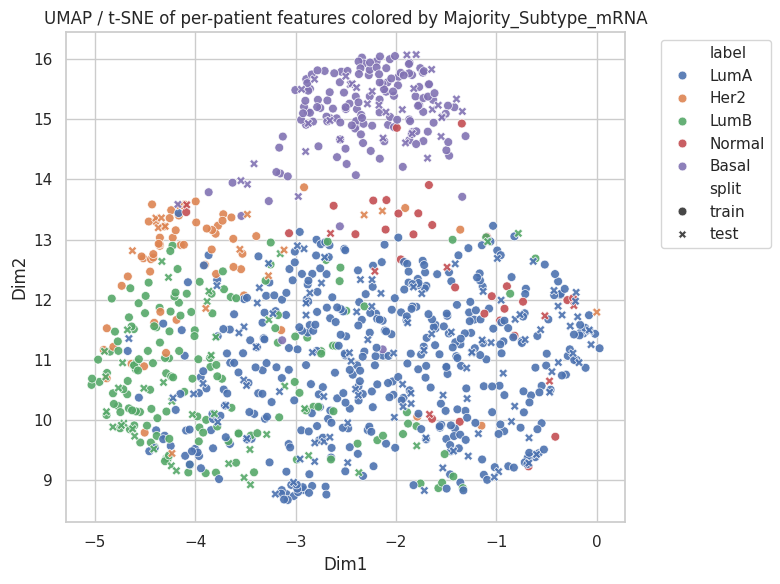

Saved embedding to /data/horse/ws/mala059b-rna2wsi/vae_output/full_train/umap_embeddings.csv


In [8]:
# Plot colored by Majority_Subtype_mRNA
plt.figure(figsize=(8,6))
ax = sns.scatterplot(data=df_plot, x='Dim1', y='Dim2', hue='label', style='split', s=40, alpha=0.9)
ax.set_title('UMAP / t-SNE of per-patient features colored by Majority_Subtype_mRNA')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Save embedding + metadata for later use
out_csv = Path('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train/umap_embeddings.csv')
df_plot.to_csv(out_csv)
print('Saved embedding to', out_csv)

In [ ]:
# Inspect encoded_mean CSV and per-dimension statistics
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
base = Path('/data/horse/ws/mala059b-rna2wsi/vae_output/full_train')
cands = list(base.glob('**/encoded_mean*.csv'))
if not cands:
    print('No encoded_mean CSV found under', base)
else:
    path = cands[0]
    print('Using', path)
    enc = pd.read_csv(path, index_col=0)
    print('shape', enc.shape)
    display(enc.head(3))
    # per-dimension standard deviation
    stds = enc.std(axis=0)
    print('per-dim std: mean {:.4f}, median {:.4f}, min {:.4f}, max {:.4f}'.format(stds.mean(), stds.median(), stds.min(), stds.max()))
    print('Top 10 most variant dims:')
    print(stds.sort_values(ascending=False).head(10))
    plt.figure(figsize=(6,3))
    sns.histplot(stds, bins=50)
    plt.xlabel('Per-dimension std')
    plt.title('Distribution of latent-dimension stds')
    plt.show()
    # Try to show label counts if available by joining clinical_table.csv
    clin_path = base / 'clinical_table.csv'
    if clin_path.exists():
        clin = pd.read_csv(clin_path, dtype=str).set_index('PATIENT')
        # if enc index matches patients, map labels
        labels = enc.index.to_series().map(lambda x: clin.loc[x]['Majority_Subtype_mRNA'] if x in clin.index else pd.NA)
        print('Label counts (mapped from clinical_table.csv):')
        print(labels.value_counts(dropna=False))
    elif 'Majority_Subtype_mRNA' in enc.columns:
        print('Label counts (embedded csv contains label column):')
        print(enc['Majority_Subtype_mRNA'].value_counts(dropna=False))